# Modeling

In this notebook we compare a simple baseline with two tree-based models and keep the test set for the final check only.

The goal is not to find the perfect model immediately, but to learn which family works better on this dataset, and explore what could we do in the future to improve the results.

In [68]:
import pandas as pd
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, recall_score, precision_score, f1_score, confusion_matrix


## Load Data

The preprocessing was already done in notebook 02, so here we only load the saved train and test splits.

The target is already mapped to numeric values, so the models receive clean labels.

In [69]:
# Load preprocessed data
X_train = pd.read_csv("../data/preprocessed/train/X_train.csv")
X_test = pd.read_csv("../data/preprocessed/test/X_test.csv")
y_train = pd.read_csv("../data/preprocessed/train/y_train.csv").iloc[:, 0]
y_test = pd.read_csv("../data/preprocessed/test/y_test.csv").iloc[:, 0]


## Logistic Regression

This is the baseline model. It is simple, fast, and gives us a reference point.

In [70]:
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [71]:
y_pred_lr = lr.predict(X_test)

print(y_pred_lr[:10])

[1 0 0 1 0 0 0 0 1 0]


## Random Forest

This model can capture non-linear patterns and interactions better than logistic regression.

In [72]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [73]:
y_pred_rf = rf.predict(X_test)

print(y_pred_rf[:10])

[0 0 0 1 0 0 0 0 1 0]


## XGBoost

This model is usually strong on tabular data, so it is a good candidate to compare against the other two.

In [74]:
xgb = XGBClassifier(random_state=42)
xgb.fit(X_train, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [75]:
y_pred_xgb = xgb.predict(X_test)

print(y_pred_xgb[:10])

[0 0 1 0 0 0 0 0 1 0]


## Cross-Validation

We use cross-validation on the training set to compare models before looking at the test set results.

In [76]:
cv_scores_lr = cross_val_score(lr, X_train, y_train, cv=5, scoring='roc_auc')
cv_scores_lr

array([0.74645503, 0.82624339, 0.83957672, 0.7221164 , 0.83428571])

In [77]:
cv_scores_rf = cross_val_score(rf, X_train, y_train, cv=5, scoring='roc_auc')
cv_scores_rf

array([0.77798942, 0.77322751, 0.83142857, 0.72042328, 0.8231746 ])

In [78]:
cv_scores_xgb = cross_val_score(xgb, X_train, y_train, cv=5, scoring='roc_auc')
cv_scores_xgb

array([0.78391534, 0.71873016, 0.82306878, 0.70920635, 0.81079365])

In [79]:
# roc_auc_score
# first predict probabilities, not classes
y_prob_lr = lr.predict_proba(X_test)[:, 1]
y_prob_rf = rf.predict_proba(X_test)[:, 1]
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

roc_auc_lr = roc_auc_score(y_test, y_prob_lr)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

# recall_score
recall_lr = recall_score(y_test, y_pred_lr)
recall_rf = recall_score(y_test, y_pred_rf)
recall_xgb = recall_score(y_test, y_pred_xgb)

# precision_score
precision_lr = precision_score(y_test, y_pred_lr)
precision_rf = precision_score(y_test, y_pred_rf)
precision_xgb = precision_score(y_test, y_pred_xgb)

# f1_score
f1_lr = f1_score(y_test, y_pred_lr)
f1_rf = f1_score(y_test, y_pred_rf)
f1_xgb = f1_score(y_test, y_pred_xgb)

In [80]:
results = pd.DataFrame({
    'model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'cv_roc_auc_mean': [cv_scores_lr.mean(), cv_scores_rf.mean(), cv_scores_xgb.mean()],
    'test_roc_auc': [roc_auc_score(y_test, y_prob_lr), roc_auc_score(y_test, y_prob_rf), roc_auc_score(y_test, y_prob_xgb)],
    'recall': [recall_lr, recall_rf, recall_xgb],
    'precision': [precision_lr, precision_rf, precision_xgb],
    'f1': [f1_lr, f1_rf, f1_xgb]
})
    
results.to_csv("../results/model_comparison.csv", index=False)
results

,model,cv_roc_auc_mean,test_roc_auc,recall,precision,f1
0,Logistic Regression,0.793735,0.769219,0.480000,0.610169,0.537313
1,Random Forest,0.785249,0.789295,0.386667,0.630435,0.479339
2,XGBoost,0.769143,0.776838,0.440000,0.550000,0.488889


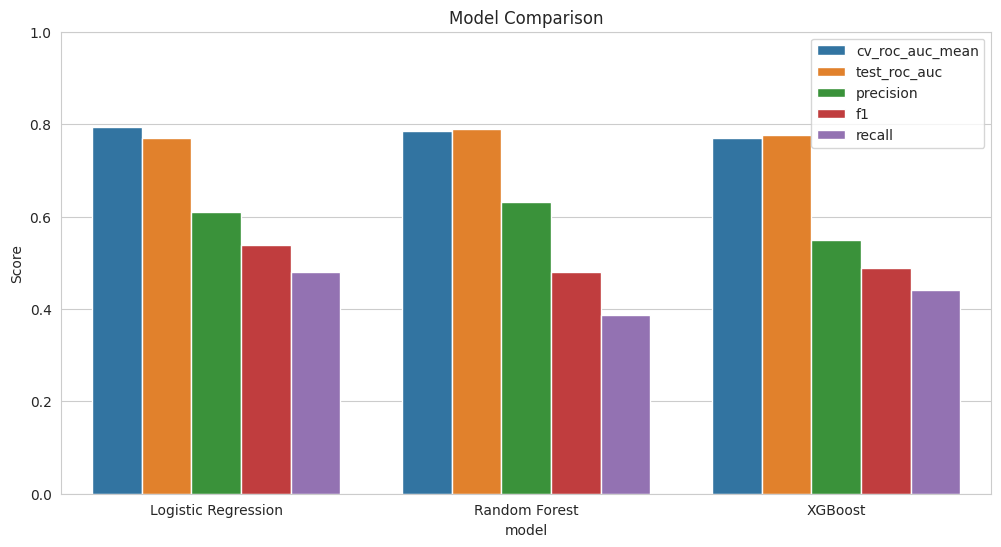

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
results_melted = results.melt(id_vars='model', var_name='metric', value_name='value').sort_values(by='value', ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x='model', y='value', hue='metric', data=results_melted)
plt.title("Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(loc='upper right')
plt.savefig("../outputs/figures/model_comparison.png")
plt.show()

In [82]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

false_negatives = cm_lr[1, 0]
false_positives = cm_lr[0, 1]

print(f"Approx. FN/FP ratio for Logistic Regression: {false_negatives / false_positives:.2f}")

Approx. FN/FP ratio for Logistic Regression: 1.70


In [83]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

false_negatives = cm_rf[1, 0]
false_positives = cm_rf[0, 1]

print(f"Approx. FN/FP ratio for Random Forest: {false_negatives / false_positives:.2f}")

Approx. FN/FP ratio for Random Forest: 2.71


In [85]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
    
false_negatives = cm_xgb[1, 0]
false_positives = cm_xgb[0, 1]

print(f"Approx. FN/FP ratio for Random Forest: {false_negatives / false_positives:.2f}")

Approx. FN/FP ratio for Random Forest: 1.56


## Business Cost Interpretation

We distinguish between class imbalance and business cost imbalance. Even if the data is around 70/30 good-bad, the business impact can still be asymmetric.

In this project, one missed bad payer is assumed to cost about 5 times more than wrongly flagging one good payer. That means model choice should prioritize recall for the bad class and cost-sensitive threshold tuning, not only accuracy.

If we define expected cost as:

$$E[C] = 5 \cdot FN + 1 \cdot FP$$

then the preferred model or threshold is the one that minimizes this value.

A starting threshold for calibrated probabilities is:

$$p(\text{bad}) > \frac{1}{1+5} \approx 0.167$$

## Research Questions and Answers

1. What is the class distribution?
The dataset is imbalanced (about 70% good, 30% bad).

2. Which features are most informative for risk?
Credit amount and duration show the strongest relation with target in EDA.

3. Are there data quality issues?
No major missing-value or duplicate issues were found.

4. What preprocessing is justified?
Log transform on skewed numeric features, scaling for numeric variables, and categorical encoding (ordinal + one-hot).

5. Which baseline models perform best?
Logistic Regression, Random Forest, and XGBoost give similar baseline performance; results suggest more gain will come from feature engineering and threshold tuning than adding many new models.

## Conclusion

This is a strong baseline study, but not a final optimized credit-risk system.

Logistic Regression is the best operational baseline if the goal is to catch bad payers with better recall and F1. Random Forest has a slightly higher ROC AUC, so it is still a valid alternative if ranking quality is prioritized more than recall.

The main takeaway is that the current feature set already carries useful signal, but the next improvement should focus on threshold tuning, class-imbalance handling, and feature engineering rather than adding many more models.

At this point, the project is ready to share publicly because the workflow is reproducible, the results are summarized clearly, and the business interpretation is explicit.